In [13]:
import mcstasscript as ms
import mcstastox as mx
import scipp as sc
from scipp.typing import VariableLike
import scipp as sc
from scippneutron.conversion.graph.beamline import beamline
import os
import sys
import numpy as np
import matplotlib.pyplot as plt 

parent = os.path.dirname(os.getcwd())

sys.path.append(parent)
from trex_reduction import inelastic
from trex_reduction import produce_trex_event_object
from trex_reduction import _calc_pulse_centroid


In [14]:

file_path = parent + "/runs/LET_vanad"

with mx.Read(file_path) as loaded_data:
    scipp_object = loaded_data.export_scipp(source_name="SourceMantid",
                                            sample_name="iso_samp")
    
data = ms.load_data(file_path)

In [15]:
# Load event data into scipp 
event_object = scipp_object
# McStas provides absolute time, not time of flight
event_object['events'].bins.coords['tof'] = event_object['events'].bins.coords['t']
# Add additional information required for inelastic scattering
# test = produce_trex_event_object(event_object['events'].bins, file_path, "Monitor6")
event_object['events'] = produce_trex_event_object(event_object['events'], file_path, "Monitor6")


qens_graph = {**beamline(scatter=True), **inelastic}
event_object['events'] = event_object['events'].transform_coords("Q", graph=qens_graph)
# event_object

In [16]:
event_object

DataGroup(sizes={'pixel_id': None, 'panel_id': 1, 'pixel': 2}, keys=[
    events: DataArray({'pixel_id': 9882}),
    positions: Variable({'pixel_id': 30056}),
    bank_ids: Variable({'panel_id': 1, 'pixel': 2}),
    bank_names: Variable({'panel_id': 1}),
])

# Calculate minimum and maximum kf

In [17]:
event_object['events']

<scipp.DataArray>
Dimensions: Sizes[pixel_id:9882, ]
Coordinates:
  L1                        float64              [m]  ()  25
  L2                        float64              [m]  (pixel_id)  [4.02385, 4.02385, ..., 4.02385, 4.02385]
  Lm                        float64              [m]  ()  23.505
  incident_beam             vector3              [m]  ()  (0, 0, 25)
  monitor_beam              vector3              [m]  ()  (0, 0, 23.505)
  monitor_position          vector3              [m]  ()  (0, 0, 23.505)
* pixel_id                    int64  [dimensionless]  (pixel_id)  [1, 2, ..., 30038, 30045]
  position                  vector3              [m]  (pixel_id)  [(-2.19208, -1.98529, 27.7285), (-2.15307, -1.98529, 27.7594), ..., (2.84063, 1.98529, 22.9553), (2.62345, 1.98529, 22.6832)]
  sample_position           vector3              [m]  ()  (0, 0, 25)
  scattered_beam            vector3              [m]  (pixel_id)  [(-2.19208, -1.98529, 2.72851), (-2.15307, -1.98529, 2.7594), ..., (2.84063, 1.98529, -2.04471), (2.62345, 1.98529, -2.31679)]
  source_position           vector3              [m]  ()  (0, 0, 0)
  unit_kf                   vector3  [dimensionless]  (pixel_id)  [(-0.544771, -0.493381, 0.678085), (-0.535077, -0.493381, 0.68576), ..., (0.705948, 0.493381, -0.508146), (0.651975, 0.493381, -0.575764)]
  unit_ki                   vector3  [dimensionless]  ()  (0, 0, 1)
Data:
                          DataArrayView        <no unit>  (pixel_id)  binned data: dim='events', content=DataArray(
          dims=(events: 12078),
          data=float64[counts],
          coords={'t':float64[s], 'tof':float64[s], 'time_on_monitor':float64[s],
                  'vi':float64[m/s], 'time_on_sample':float64[s], 'mag_ki':float64[1/Å],
                  'vf':float64[m/s], 'ki':vector3[1/Å], 'mag_kf':float64[1/Å],
                  'kf':vector3[1/Å], 'Q':vector3[1/Å]})

In [43]:
from scipy.ndimage import label

Lm =  event_object['events'].coords['Lm']

def _calc_mag_kf_from_ef(ef):
    hbar = sc.constants.hbar
    m_n = sc.constants.neutron_mass
    kf = sc.sqrt(2 * m_n * ef) / hbar
    return kf.to(unit='1/angstrom')


monitor = ms.name_search("Monitor6", data)
tom_centroid = _calc_pulse_centroid(monitor)
vi = Lm / tom_centroid

ei = (0.5 * sc.constants.m_n * vi**2).to(unit='meV')


unit_ki = event_object['events'].coords['unit_ki']
mag_ki = ((sc.constants.neutron_mass * vi) / sc.constants.hbar).to(unit='1/angstrom')


ki = unit_ki * mag_ki



prop_ei = 0.8
max_ef = (1+prop_ei) * ei
min_ef = (1-prop_ei) * ei

min_kf = _calc_mag_kf_from_ef(min_ef)
max_kf = _calc_mag_kf_from_ef(max_ef)

print(f'min_kf: {min_kf}, max_kf: {max_kf}')


min_kf: <scipp.Variable> (tof: 1)    float64            [1/Å]  [0.595902], max_kf: <scipp.Variable> (tof: 1)    float64            [1/Å]  [1.78771]


# Access and calculate detector pixel Qs

tan(theta) = x_vec / z_vec

In [44]:
sample_position = event_object['events'].coords['sample_position']
pixel_vec = event_object['positions'] - sample_position
pixel_vec = pixel_vec / sc.norm(pixel_vec)

Q_max = ki.to(unit = '1/Angstrom') - (pixel_vec * max_kf).to(unit = '1/Angstrom')
Q_min = ki.to(unit = '1/Angstrom') - (pixel_vec * min_kf).to(unit = '1/Angstrom')


# theta = sc.atan2(x = pixel_vec.fields['z'], y = pixel_vec.fields['x'])
# phi = sc.atan2(x = pixel_vec.fields['x'], y = pixel_vec.fields['y'])

# kf_max_x = max_kf * sc.sin(theta) * sc.cos(phi)
# kf_max_y = max_kf * sc.sin(theta) * sc.sin(phi) 
# kf_max_z = max_kf * sc.cos(theta)


# kf_max = sc.vectors(
#     dims=['pixel_id'],
#     values=np.stack([kf_max_x.values, kf_max_y.values, kf_max_z.values], axis=-1),
#     unit=kf_max_x.unit
# )

# kf_min_x = min_kf * sc.sin(theta) * sc.cos(phi)
# kf_min_y = min_kf * sc.sin(theta) * sc.sin(phi)
# kf_min_z = min_kf * sc.cos(theta)


# kf_min = sc.vectors(
#     dims=['pixel_id'],
#     values=np.stack([kf_min_x.values, kf_min_y.values, kf_min_z.values], axis=-1),
#     unit=kf_min_x.unit
# )


# kf_max = sc.vector([kf_max_x, kf_max_y, kf_max_z])

# pixel_unit_kf = pixel_kf / sc.norm(pixel_kf)
# pixel_Q_vector = unit_ki - pixel_unit_kf

# pixel_Q_vector

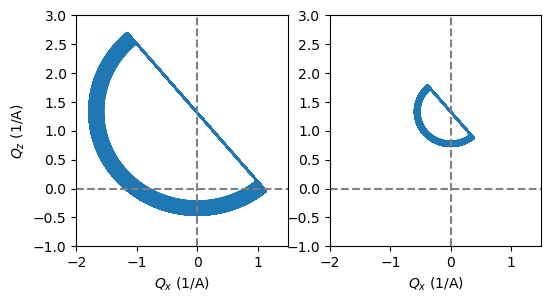

In [50]:
fig, [ax1,ax2] = plt.subplots(1,2, figsize= (6,3))
ax1.plot(Q_max.values[:,:,0], Q_max.values[:,:,2])
ax2.plot(Q_min.values[:,:,0], Q_min.values[:,:,2])

for ax in [ax1, ax2]:
    ax.set_xlim(-2,1.5)
    ax.set_ylim(-1,3)
    ax.axvline(0, color='grey', linestyle='--')
    ax.axhline(0, color='grey', linestyle='--')
    ax.set_xlabel(r'$Q_x$ (1/A)')
    ax1.set_ylabel(r'$Q_z$ (1/A)')